In [1]:
sovi_vars = [
    "QPOVTY", "QCVLUN", "QED12LES", "QFHH", "QESL", "QAGEDEP", "QFEMALE",
    "QFEMLBR", "QRICH", "QSERV", "QEXTRCT", "QMOHO", "QNOAUTO",
    "MDGRENT", "MDHSEVAL", "PPUNIT", "QRENTER", "QSSBEN", "QHSEBRDN",
    "MEDAGE", "PERCAP", "QBLACK", "QASIAN", "QHISP", "QFAM", "QNOHLTH"
]

In [ ]:
# Just some ideas I had for comparing the effectiveness of SoVI quartiles or quintiles versus k-means with 
# 4 or 5 clusters, per our Feb 19 meeting discussion about "why clustering"

In [5]:
import pandas as pd
import geopandas as gpd
from statsmodels.formula.api import ols

# 1. Processing 2010-2019 with yearly quintiles
all_dfs = []
for yr in range(2010, 2020):
    s = gpd.read_file(f"../data/sovi_data/optimized_sovi/sovi-optimized_{yr}.gpkg")
    k = gpd.read_file(f"../data/testing_data/k-means5/K5-sovi_{yr}.gpkg")
    
    s['sovi_quintile'] = pd.qcut(s['SoVI_Score'], 5, labels=[1, 2, 3, 4, 5])
    
    merged = s[['GEOID', 'sovi_quintile'] + sovi_vars].merge(
        k[['GEOID', 'vulnerability_rank']], on='GEOID'
    )
    all_dfs.append(merged)

df = pd.concat(all_dfs, ignore_index=True)

# 2. Calculate R2 for every single variable
res_list = []
for v in sovi_vars:
    r2_s = ols(f"{v} ~ C(sovi_quintile)", data=df).fit().rsquared
    r2_k = ols(f"{v} ~ C(vulnerability_rank)", data=df).fit().rsquared
    res_list.append({
        'Variable': v, 
        'SoVI_R2': r2_s, 
        'KMeans_R2': r2_k,
    })

# 3. Display as a clean table
df_results = pd.DataFrame(res_list).sort_values('SoVI_R2', ascending=False)
print(df_results.to_string(index=False))

# 4. Global average for context
print(f"\nMean SoVI R2: {df_results['SoVI_R2'].mean():.4f}")
print(f"Mean KMeans-5 R2: {df_results['KMeans_R2'].mean():.4f}")
print("")



# 1.1. Processing 2010-2019 with yearly quartiles
all_dfs = []
for yr in range(2010, 2020):
    s = gpd.read_file(f"../data/sovi_data/optimized_sovi/sovi-optimized_{yr}.gpkg")
    k = gpd.read_file(f"../data/testing_data/k-means4/K4-sovi_{yr}.gpkg")
    
    s['sovi_quartile'] = pd.qcut(s['SoVI_Score'], 4, labels=[1, 2, 3, 4])
    
    merged = s[['GEOID', 'sovi_quartile'] + sovi_vars].merge(
        k[['GEOID', 'vulnerability_rank']], on='GEOID'
    )
    all_dfs.append(merged)

df = pd.concat(all_dfs, ignore_index=True)

# 2.1. Calculate R2 for every single variable
res_list = []
for v in sovi_vars:
    r2_s = ols(f"{v} ~ C(sovi_quartile)", data=df).fit().rsquared
    r2_k = ols(f"{v} ~ C(vulnerability_rank)", data=df).fit().rsquared
    res_list.append({
        'Variable': v, 
        'SoVI_R2': r2_s, 
        'KMeans_R2': r2_k,
    })

# 3.1. Display as a clean table
df_results = pd.DataFrame(res_list).sort_values('SoVI_R2', ascending=False)
print(df_results.to_string(index=False))

# 4.1. Global average for context
print(f"\nMean SoVI R2: {df_results['SoVI_R2'].mean():.4f}")
print(f"Mean KMeans-4 R2: {df_results['KMeans_R2'].mean():.4f}")





Variable  SoVI_R2  KMeans_R2
    QFHH 0.407121   0.561603
  PERCAP 0.325277   0.719018
MDHSEVAL 0.311464   0.628970
QED12LES 0.299712   0.541091
   QRICH 0.250548   0.654928
  QPOVTY 0.244837   0.592270
 QNOHLTH 0.240166   0.466060
    QFAM 0.234937   0.567256
  QBLACK 0.213501   0.613728
QHSEBRDN 0.204480   0.539312
   QSERV 0.197462   0.403781
  QSSBEN 0.185261   0.415293
  QCVLUN 0.182048   0.381624
 QFEMALE 0.164695   0.066914
 QAGEDEP 0.157140   0.174492
   QHISP 0.152959   0.568865
 QNOAUTO 0.149568   0.513257
 QEXTRCT 0.137781   0.370112
    QESL 0.136439   0.591283
   QMOHO 0.117889   0.572852
 QRENTER 0.111168   0.512898
 QFEMLBR 0.101881   0.174759
  QASIAN 0.099397   0.288603
  MEDAGE 0.082496   0.425870
 MDGRENT 0.070474   0.434097
  PPUNIT 0.056151   0.018430

Mean SoVI R2: 0.1860
Mean KMeans-5 R2: 0.4537

Variable  SoVI_R2  KMeans_R2
    QFHH 0.387357   0.574659
  PERCAP 0.313220   0.665478
MDHSEVAL 0.296677   0.573048
QED12LES 0.290341   0.456649
  QPOVTY 0.237181   0.57

In [ ]:
# Based on OLS, k-means is better at creating interpretable clusters of data. 
# Maybe we try removing variables with low R2 and seeing how that improves the clustering and PCA algorithms?

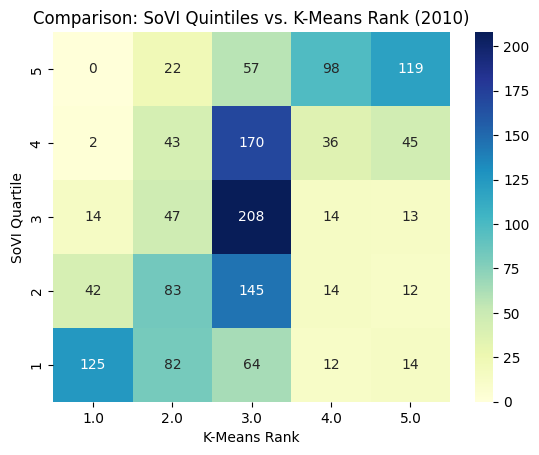

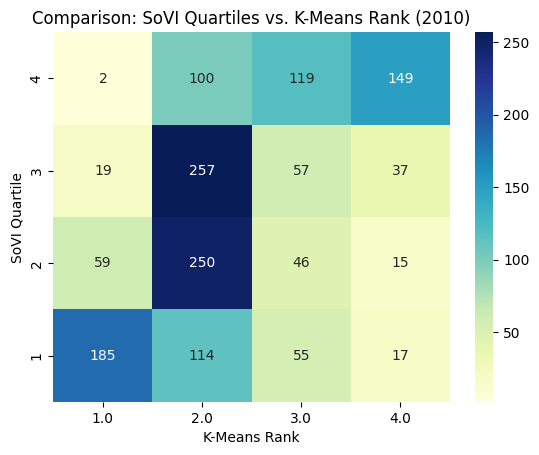

In [7]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

year = 2010

# Read data
df_s = gpd.read_file(f"../data/sovi_data/optimized_sovi/sovi-optimized_{year}.gpkg")
df_k = gpd.read_file(f"../data/testing_data/k-means5/K5-sovi_{year}.gpkg")

# Create quartile labels (1 to 5) based on the score
# 1 = Lowest vulnerability, 5 = Highest vulnerability
df_s['sovi_quintile'] = pd.qcut(df_s['SoVI_Score'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Merge the two dataframes on GEOID
df_compare = df_s[['GEOID', 'sovi_quintile']].merge(
    df_k[['GEOID', 'vulnerability_rank']], 
    on='GEOID'
)

# 1. Generate frequency table
comparison_matrix = pd.crosstab(
    df_compare['sovi_quintile'], 
    df_compare['vulnerability_rank'],
    rownames=['SoVI Quartile'], 
    colnames=['K-Means Rank']
)

comparison_matrix_flipped = comparison_matrix.iloc[::-1]
sns.heatmap(comparison_matrix_flipped, annot=True, fmt="d", cmap="YlGnBu")

# Formatting
plt.title(f"Comparison: SoVI Quintiles vs. K-Means Rank ({year})")
plt.xlabel("K-Means Rank")
plt.ylabel("SoVI Quartile")
plt.show()



# Read data
df_s = gpd.read_file(f"../data/sovi_data/optimized_sovi/sovi-optimized_{year}.gpkg")
df_k = gpd.read_file(f"../data/testing_data/k-means4/K4-sovi_{year}.gpkg")

# Create quartile labels (1 to 4) based on the score
# 1 = Lowest vulnerability, 4 = Highest vulnerability
df_s['sovi_quartile'] = pd.qcut(df_s['SoVI_Score'], 4, labels=[1, 2, 3, 4]).astype(int)

# Merge the two dataframes on GEOID
df_compare = df_s[['GEOID', 'sovi_quartile']].merge(
    df_k[['GEOID', 'vulnerability_rank']], 
    on='GEOID'
)

# 1. Generate frequency table
comparison_matrix = pd.crosstab(
    df_compare['sovi_quartile'], 
    df_compare['vulnerability_rank'],
    rownames=['SoVI Quartile'], 
    colnames=['K-Means Rank']
)

comparison_matrix_flipped = comparison_matrix.iloc[::-1]
sns.heatmap(comparison_matrix_flipped, annot=True, fmt="d", cmap="YlGnBu")

# Formatting
plt.title(f"Comparison: SoVI Quartiles vs. K-Means Rank ({year})")
plt.xlabel("K-Means Rank")
plt.ylabel("SoVI Quartile")
plt.show()



In [ ]:
import pandas as pd
import geopandas as gpd
from libpysal.weights import Queen
from esda.moran import Moran

results_moran = []

# We iterate by year because Moran's I requires a valid spatial weights matrix (W)
# for the specific geometries of that year.
for yr in range(2010, 2020):
    # 1. Load data
    s = gpd.read_file(f"../data/sovi_data/optimized_sovi/sovi-optimized_{yr}.gpkg")
    k = gpd.read_file(f"../data/testing_data/k-means5/K5-sovi_{yr}.gpkg")
    
    # Pre-processing 
    s['sovi_quintile'] = pd.qcut(s['SoVI_Score'], 5, labels=[1, 2, 3, 4, 5])
    merged = s.merge(k[['GEOID', 'vulnerability_rank']], on='GEOID')
    
    # 2. Build Spatial Weights Matrix (Queen contiguity)
    # Row-standardize (transform='R') is standard for Moran's I
    w = Queen.from_dataframe(merged)
    w.transform = 'R'
    
    # 3. Calculate Moran's I for each individual SoVI variable
    year_vars_moran = {}
    for v in sovi_vars:
        mi = Moran(merged[v], w)
        year_vars_moran[v] = mi.I
        
    # 4. Calculate Moran's I for the Cluster/Quintile Rankings
    mi_sovi = Moran(merged['sovi_quintile'].astype(float), w).I
    mi_kmeans = Moran(merged['vulnerability_rank'].astype(float), w).I
    
    results_moran.append({
        'Year': yr,
        'SoVI_Quintile_I': mi_sovi,
        'KMeans_Cluster_I': mi_kmeans,
        **year_vars_moran
    })

# 5. Process Results
df_moran = pd.DataFrame(results_moran)

# Calculate Mean Moran's I across all years for each variable
mean_moran = df_moran.drop(columns=['Year']).mean().sort_values(ascending=False)

print("--- Average Global Moran's I (2010-2019) ---")
print(mean_moran.to_string())

<positron-console-cell-13>:22: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
<positron-console-cell-13>:22: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
<positron-console-cell-13>:22: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
<positron-console-cell-13>:22: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
<positron-console-cell-13>:22: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
<positron-console-cell-13>:22: FutureWarning: `use_index` defaults to 

--- Average Global Moran's I (2010-2019) ---
QBLACK              0.804117
MDHSEVAL            0.675838
QMOHO               0.669856
QSSBEN              0.605872
PERCAP              0.589651
QRICH               0.552873
MDGRENT             0.538515
QED12LES            0.532245
QPOVTY              0.514700
QRENTER             0.514617
KMeans_Cluster_I    0.510113
QHSEBRDN            0.495858
QFHH                0.480633
QFAM                0.471164
QNOAUTO             0.469703
QESL                0.466932
MEDAGE              0.454285
QASIAN              0.426551
QHISP               0.425259
QEXTRCT             0.415577
QNOHLTH             0.398220
PPUNIT              0.392046
QCVLUN              0.380999
QAGEDEP             0.351343
QSERV               0.348725
SoVI_Quintile_I     0.344559
QFEMLBR             0.174538
QFEMALE             0.069812


In [ ]:
# Is it significant at all that the SoVI quintiles are less spatially correlated than almost 
# every variable? My interpretation here is that k-means clusters are "better" at capturing the 
# spatial distribution of these variables. 

# Of course, though, I could also explore geographically weighted clustering.